In [ ]:
#sudo apt update
#sudo apt install -y python3 python3-venv python3-pip
#python3 -V                    # sanity check
#python3 -m venv .venv
#source .venv/bin/activate
#python -m pip install --upgrade pip
#pip install torch transformers evaluate rouge-score pandas
#python -m pip install --upgrade pip setuptools wheel
#pip install "bitsandbytes>=0.43.3" accelerate
#pip install scikit-learn
#pip install transformers datasets torch scikit-learn pandas matplotlib

In [1]:
# =========================
# 1) Setup and Data Loading
# =========================
import os, random, math
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)



/home/coder/Text-Classification-Using-DistilBERT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


Saved test set → Data/test_set.parquet
Train: 98000 | Val: 28000 | Test: 14000
Train counts:
 label
0     7000
1     7000
2     7000
3     7000
4     7000
5     7000
6     7000
7     7000
8     7000
9     7000
10    7000
11    7000
12    7000
13    7000
Name: count, dtype: int64

Val counts:
 label
0     2000
1     2000
2     2000
3     2000
4     2000
5     2000
6     2000
7     2000
8     2000
9     2000
10    2000
11    2000
12    2000
13    2000
Name: count, dtype: int64

Test counts:
 label
0     1000
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8     1000
9     1000
10    1000
11    1000
12    1000
13    1000
Name: count, dtype: int64


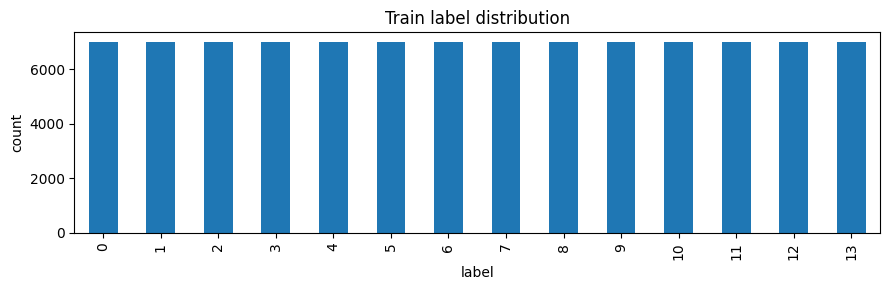

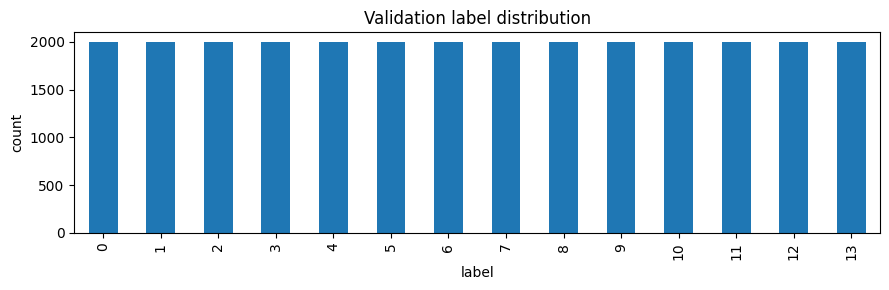

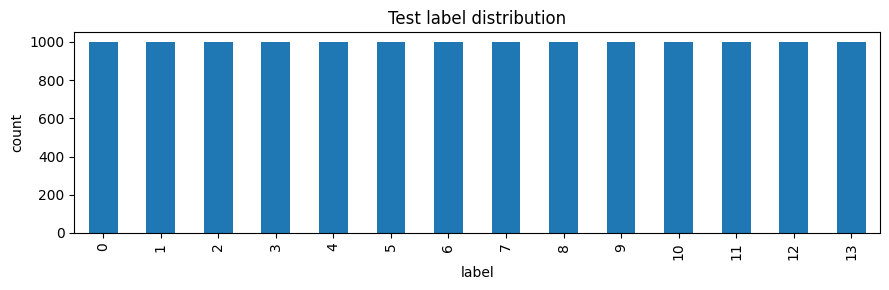

In [2]:
# Load dataset.parquet
df = pd.read_parquet("Data/dataset.parquet")

# =========================
# Split: train / val / test
# We use 70/20/10 so validation is exactly 0.20.
# =========================
train_df, rest_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)
val_df, test_df = train_test_split(
    rest_df, test_size=(1/3), random_state=42, stratify=rest_df["label"]
)

os.makedirs("Data", exist_ok=True)
test_df.to_parquet("Data/test_set.parquet", index=False)
print("Saved test set → Data/test_set.parquet")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


def show_dist(name, s):
    ax = s.value_counts().sort_index().plot(kind="bar", figsize=(9,3))
    ax.set_title(f"{name} label distribution")
    ax.set_xlabel("label")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

print("Train counts:\n", train_df["label"].value_counts().sort_index())
print("\nVal counts:\n",   val_df["label"].value_counts().sort_index())
print("\nTest counts:\n",  test_df["label"].value_counts().sort_index())
show_dist("Train", train_df["label"])
show_dist("Validation", val_df["label"])
show_dist("Test", test_df["label"])

In [3]:
# =========================
# 2) Preprocessing
# =========================

df_cols = ["title", "content"]
for col in df_cols:
    for d in (train_df, val_df, test_df):
        if col not in d.columns:
            d[col] = ""

for d in (train_df, val_df, test_df):
    d["text"] = d["title"].fillna("") + " [SEP] " + d["content"].fillna("")

# Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
MAX_LEN = 512

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

# Build HF datasets
from datasets import Dataset
train_ds = Dataset.from_pandas(train_df[["text","label"]], preserve_index=False).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df[["text","label"]],   preserve_index=False).map(tokenize, batched=True)
test_ds  = Dataset.from_pandas(test_df[["text","label"]],  preserve_index=False).map(tokenize, batched=True)

cols = ["input_ids","attention_mask","label"]
for ds in (train_ds, val_ds, test_ds):
    ds.set_format(type="torch", columns=cols)

# DataLoaders
BATCH_SIZE = 16  
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Verify and report tokenized sample shapes (train/val/test)
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    b = next(iter(loader))
    print(
        f"{name}: input_ids {tuple(b['input_ids'].shape)}, "
        f"attention_mask {tuple(b['attention_mask'].shape)}, "
        f"labels {tuple(b['label'].shape)}"
    )


Map: 100%|██████████| 14000/14000 [00:02<00:00, 4810.40 examples/s]

train: input_ids (16, 512), attention_mask (16, 512), labels (16,)
val: input_ids (16, 512), attention_mask (16, 512), labels (16,)
test: input_ids (16, 512), attention_mask (16, 512), labels (16,)


In [4]:
# =========================
# 3) Model Exploration (before training)
# =========================
num_labels = df["label"].nunique()
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
).to(device)

cfg = model.distilbert.config
arch_info = {
    "n_transformer_blocks": cfg.n_layers,
    "n_attention_heads": cfg.n_heads,
    "hidden_size": cfg.dim,
    "ffn_dim": cfg.hidden_dim,         
    "activation": cfg.activation
}
print(arch_info)
print("linear_layers_in_ffn_per_block = 2") 


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'n_transformer_blocks': 6, 'n_attention_heads': 12, 'hidden_size': 768, 'ffn_dim': 3072, 'activation': 'gelu'}
linear_layers_in_ffn_per_block = 2


DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Tokens: ['[CLS]', 'a', 'robot', 'may', 'not', 'in', '##jure', 'a', 'human', 'being', 'or', ',', 'through', 'ina', '##ction', ',', 'allow', 'a', 'human', 'being', 'to', 'come', 'to', 'harm', '.', '[SEP]']


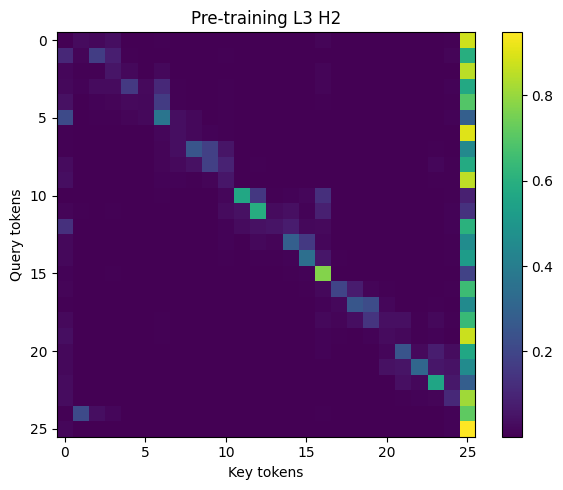

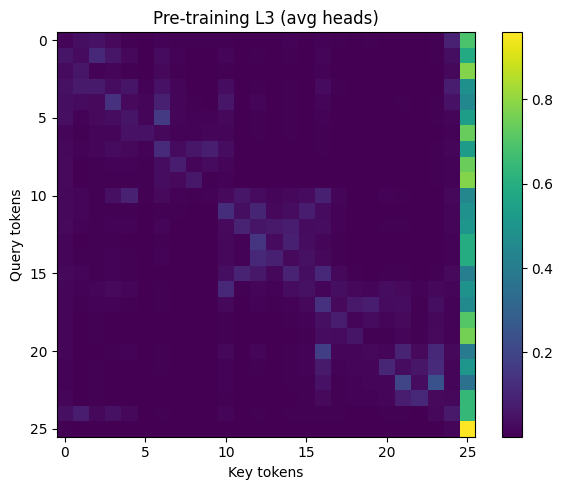

In [5]:
# =========================
# 4) Attention Visualization (pre-training)
# =========================
import numpy as np

sentence = "A robot may not injure a human being or, through inaction, allow a human being to come to harm."
tokens = tokenizer(sentence, return_tensors="pt")
tokens = {k: v.to(device) for k, v in tokens.items()}

model.eval()
with torch.no_grad():
    out_pre = model(**tokens, output_attentions=True)


attns_pre = [a.squeeze(0).detach().cpu().numpy() for a in out_pre.attentions]


layer_id = 3            
head_id  = 2            

head_map_pre = attns_pre[layer_id][head_id]      
avg_map_pre  = attns_pre[layer_id].mean(axis=0)  

def heatmap(mat, title, fname):
    plt.figure(figsize=(6,5))
    plt.imshow(mat, aspect="auto")
    plt.title(title)
    plt.xlabel("Key tokens")
    plt.ylabel("Query tokens")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    plt.show()

tok_ids = tokens["input_ids"][0].tolist()
labels = tokenizer.convert_ids_to_tokens(tok_ids)
print("Tokens:", labels)

heatmap(head_map_pre, f"Pre-training L{layer_id} H{head_id}", "attn_pre_head.png")
heatmap(avg_map_pre,  f"Pre-training L{layer_id} (avg heads)", "attn_pre_avg.png")


In [6]:
# =========================
# 5) Training
# Track training loss, validation loss, and validation accuracy.
# Save best checkpoint based on validation accuracy.
# =========================
from tqdm.auto import tqdm

EPOCHS = 10
LR = 2e-5
WEIGHT_DECAY = 0.01
GRAD_ACCUM_STEPS = 1

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

steps_per_epoch_nominal = math.ceil(len(train_ds) / BATCH_SIZE)
total_steps = steps_per_epoch_nominal * EPOCHS
warmup_steps = max(1, int(0.10 * total_steps))

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

scaler = GradScaler(enabled=(device.type == "cuda"))

def run_val_loss_acc(model, loader):
    model.eval()
    preds, golds = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["label"]
            )
            total_loss += out.loss.item()
            preds.extend(out.logits.argmax(1).detach().cpu().tolist())
            golds.extend(batch["label"].detach().cpu().tolist())
    val_loss = total_loss / len(loader)
    val_acc = accuracy_score(golds, preds)
    return val_loss, val_acc

train_loss_hist, val_loss_hist, val_acc_hist = [], [], []
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(enumerate(train_loader, start=1), total=len(train_loader))
    for step, batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        with autocast(device_type="cuda", enabled=(device.type == "cuda")):
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["label"]
            )
            loss = out.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        running += loss.item() * GRAD_ACCUM_STEPS

        if step % GRAD_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        pbar.set_description(f"Epoch {epoch} | train_loss={running/step:.4f}")

    train_loss = running / len(train_loader)
    val_loss, val_acc = run_val_loss_acc(model, val_loader)
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")
        print("✓ Saved best_model.pt")



  0%|          | 0/6125 [00:00<?, ?it/s]

Epoch 1 | train_loss=0.3837: 100%|██████████| 6125/6125 [06:52<00:00, 14.85it/s]


Epoch 1: train_loss=0.3837 | val_loss=0.0526 | val_acc=0.9865
✓ Saved best_model.pt


Epoch 2 | train_loss=0.0339: 100%|██████████| 6125/6125 [06:51<00:00, 14.87it/s]


Epoch 2: train_loss=0.0339 | val_loss=0.0413 | val_acc=0.9894
✓ Saved best_model.pt


...

Epoch 8: train_loss=0.0007 | val_loss=0.0762 | val_acc=0.9898


Epoch 9 | train_loss=0.0002: 100%|██████████| 6125/6125 [06:52<00:00, 14.86it/s]


Epoch 9: train_loss=0.0002 | val_loss=0.0820 | val_acc=0.9900


Epoch 10 | train_loss=0.0001: 100%|██████████| 6125/6125 [06:52<00:00, 14.85it/s]


Epoch 10: train_loss=0.0001 | val_loss=0.0858 | val_acc=0.9901


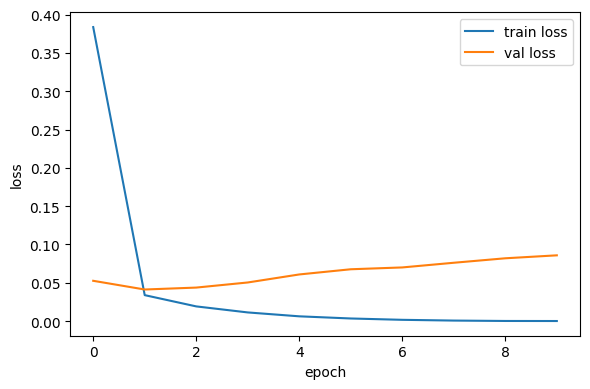

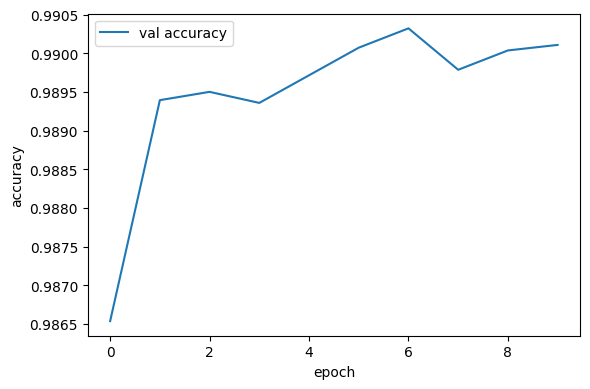

In [7]:
# Training curves 
plt.figure(figsize=(6,4))
plt.plot(train_loss_hist, label="train loss")
plt.plot(val_loss_hist, label="val loss")
plt.legend()
plt.xlabel("epoch"); plt.ylabel("loss"); plt.tight_layout()
plt.savefig("training_losses.png", dpi=300); plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_acc_hist, label="val accuracy")
plt.legend()
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.tight_layout()
plt.savefig("val_accuracy.png", dpi=300); plt.show()
